# Find a Elasticsearch Data Exploration
This notebook connects to the local Elasticsearch instance to explore, aggregate, and query the Open Contracting dataset we just ingested.

In [1]:
from elasticsearch import Elasticsearch
import pandas as pd
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connect to local Elasticsearch
es = Elasticsearch("http://localhost:9200")
INDEX_NAME = "fts_contracts"

# Verify connection and count documents
count_res = es.count(index=INDEX_NAME)
print(f"Total contracts indexed: {count_res['count']}")

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

Total contracts indexed: 282422


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 1. Data Aggregations
Let's look at the top buyers by contract volume.

In [3]:
agg_query = {
    "size": 0,
    "aggs": {
        "top_buyers": {
            "terms": {
                "field": "buyer_name",
                "size": 10
            }
        }
    }
}

res = es.search(index=INDEX_NAME, body=agg_query)
buckets = res['aggregations']['top_buyers']['buckets']

df_buyers = pd.DataFrame(buckets)
df_buyers.columns = ['Buyer Name', 'Contract Count']
df_buyers

,Buyer Name,Contract Count
0,Surrey County Council,6565
1,NHS England,4614
2,The Common Services Agency (more commonly know...,3831
3,Ministry of Defence,3263
4,Lincolnshire County Council,3236
5,Milton Keynes Council,2884
6,Midlands and Lancashire Commissioning Support ...,2524
7,Cumbria County Council,2473
8,NHS Wales Shared Services Partnership-Procurem...,2448
9,London Borough of Haringey - Passenger Transpo...,2081


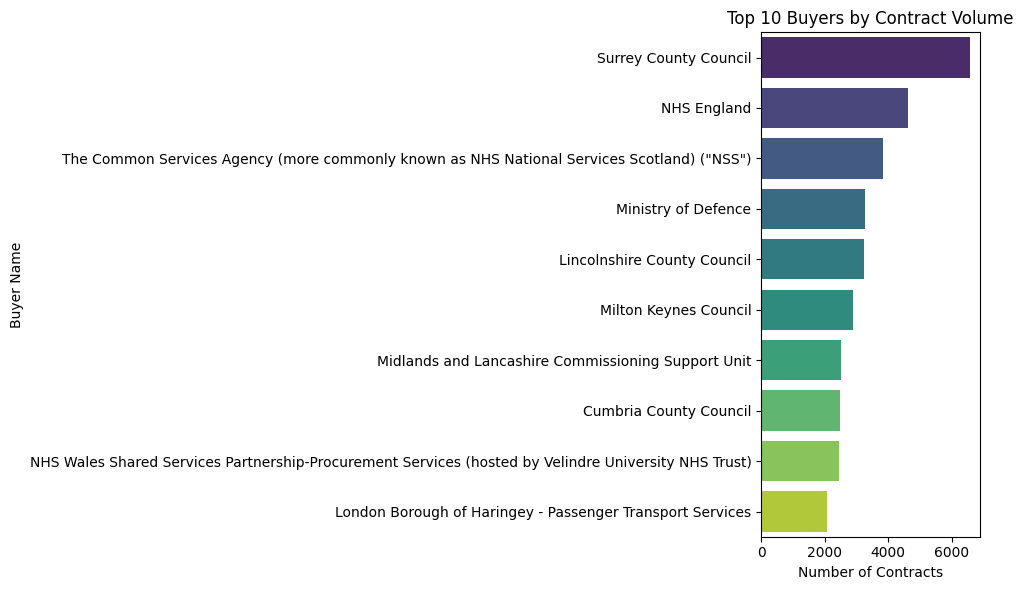

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_buyers, x='Contract Count', y='Buyer Name', hue='Buyer Name', legend=False, palette='viridis')
plt.title('Top 10 Buyers by Contract Volume')
plt.xlabel('Number of Contracts')
plt.ylabel('Buyer Name')
plt.tight_layout()
plt.show()

Let's also look at the Procurement Methods being used:

In [5]:
method_query = {
    "size": 0,
    "aggs": {
        "methods": {
            "terms": {
                "field": "procurement_method"
            }
        }
    }
}

res_methods = es.search(index=INDEX_NAME, body=method_query)
df_methods = pd.DataFrame(res_methods['aggregations']['methods']['buckets'])
df_methods.columns = ['Procurement Method', 'Contract Count']
df_methods

,Procurement Method,Contract Count
0,open,144470
1,selective,43391
2,limited,42545
3,Unknown,31074
4,direct,20942


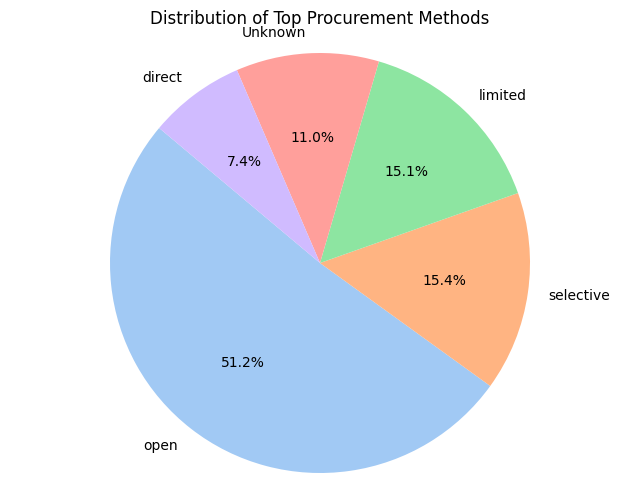

In [6]:
plt.figure(figsize=(8, 6))
# Filter out empty procurement methods for a cleaner chart if needed
df_methods_plot = df_methods[df_methods['Procurement Method'] != '']
plt.pie(df_methods_plot['Contract Count'], labels=df_methods_plot['Procurement Method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Top Procurement Methods')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Let's also look at the Contract Status:

In [7]:
method_query = {
    "size": 0,
    "aggs": {
        "methods": {
            "terms": {
                "field": "contract_status"
            }
        }
    }
}

res_methods = es.search(index=INDEX_NAME, body=method_query)
df_methods = pd.DataFrame(res_methods['aggregations']['methods']['buckets'])
df_methods.columns = ['Contract Status', 'Contract Count']
df_methods

,Contract Status,Contract Count
0,active,216437
1,,65457
2,terminated,323
3,cancelled,201
4,Abandonment of Lot 3 as per letter issued,1
5,Challenge to contract award,1
6,This UK12 Notice is being issued to cancel the...,1
7,Unknown,1


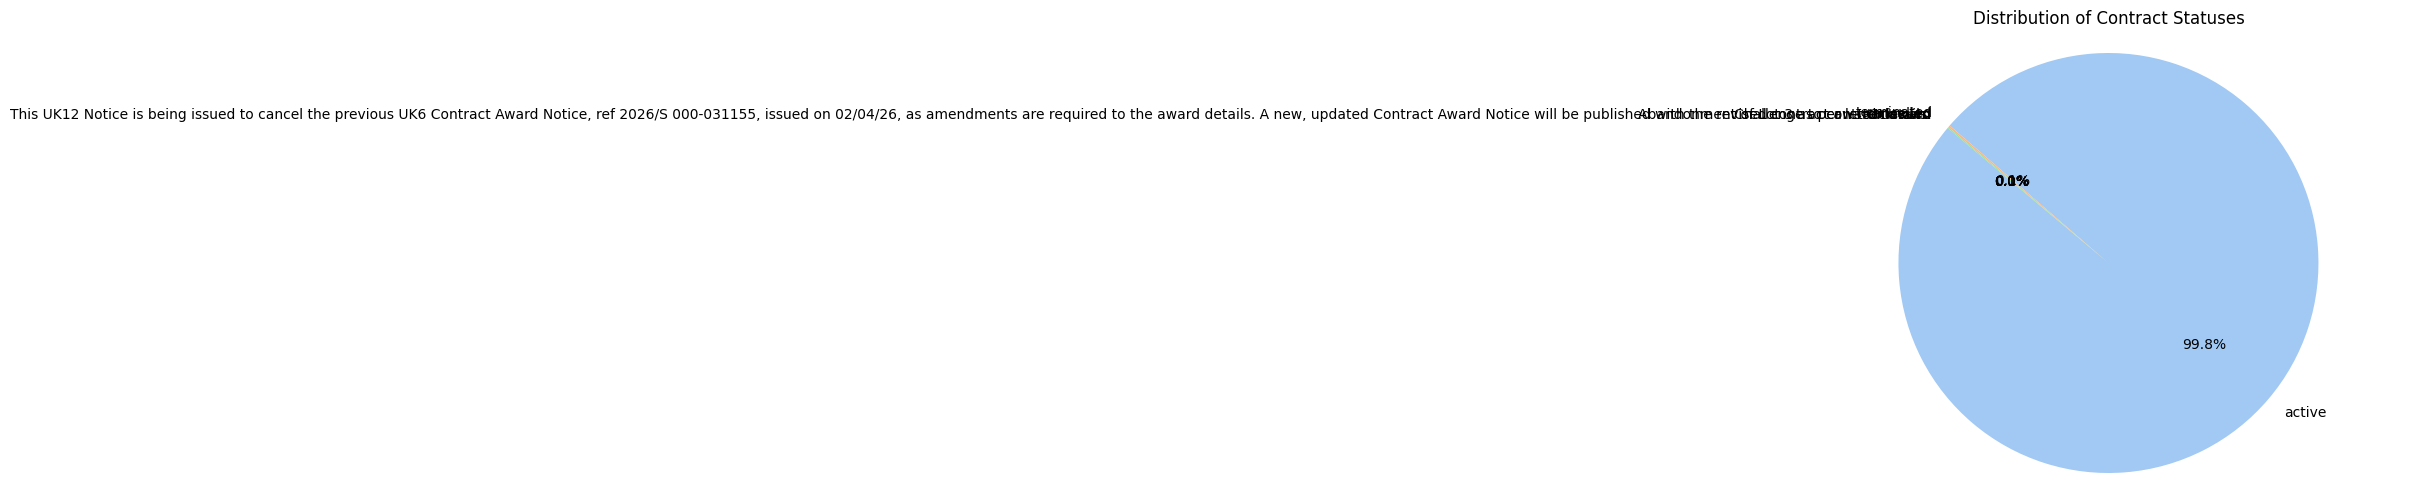

In [8]:
plt.figure(figsize=(8, 6))
# Filter out empty contract statuses for a cleaner chart if needed
df_methods_plot = df_methods[df_methods['Contract Status'] != '']
plt.pie(df_methods_plot['Contract Count'], labels=df_methods_plot['Contract Status'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Contract Statuses')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## 2. Retrieve Sample Contracts via Semantic Search
We use the sentence-transformers model `all-MiniLM-L6-v2` to embed our natural language query, and run a k-Nearest Neighbors search against the `embedding` field.

In [9]:
user_query = "framework agreements for IT services or cloud computing"
query_vector = model.encode(user_query).tolist()

search_query = {
    "knn": {
        "field": "embedding",
        "query_vector": query_vector,
        "k": 5,
        "num_candidates": 50
    },
    "_source": ["title", "buyer_name", "supplier_names", "value_amount", "contract_status"]
}

res_search = es.search(index=INDEX_NAME, body=search_query)

results = []
for hit in res_search['hits']['hits']:
    src = hit['_source']
    results.append({
        "Score": hit['_score'],
        "Title": src.get("title"),
        "Buyer": src.get("buyer_name"),
        "Supplier(s)": ", ".join(src.get("supplier_names", [])),
        "Value": src.get("value_amount"),
        "Status": src.get("contract_status")
    })

pd.set_option('display.max_colwidth', None)
pd.DataFrame(results)

,Score,Title,Buyer,Supplier(s),Value,Status
0,0.824706,IT Partner Framework,YORKSHIRE WATER SERVICES LIMITED,,0.0,
1,0.807854,Cloud Compute,The Minister for the Cabinet Office acting through Crown Commercial Service,Frontier Technology Ltd,750000000.0,active
2,0.807734,Cloud Compute,Crown Commercial Service,Frontier Technology Ltd,750000000.0,active
3,0.805698,Cloud Compute,The Minister for the Cabinet Office acting through Crown Commercial Service,Microsoft Limited,72500000.0,active
4,0.804753,Cloud Compute,Crown Commercial Service,IBM United Kingdom Limited,750000000.0,active
